# Reinforcement Learning — David Silver's UCL Course (Lectures 6–10)

The second half of my implementations from David Silver's [RL course](https://www.davidsilver.uk/teaching/)
(UCL), following on from lectures 1–5. Covers function approximation, policy-gradient methods,
model-based/planning methods, and exploration strategies — all implemented from scratch with NumPy.

**Contents**
- Lecture 6: Value Function Approximation — Linear SARSA (coarse coding & RBF features) on Mountain Car; LSPI-TD on Chain Walk
- Lecture 7: Policy Gradient — REINFORCE on PuckWorld; Q Actor-Critic (QAC)
- Lecture 8: Integrating Learning and Planning — Dyna-Q, Dyna-Q+, and Dyna-AC on a static and a dynamic maze
- Lecture 9: Exploration and Exploitation — UCB for multi-armed bandits


### Value Function Approximation
$$\hat{v}(s, \mathbf{w}) \approx v_{\pi}(s)$$

$$\text{or } \hat{q}(s, a, \mathbf{w}) \approx q_{\pi}(s, a)$$

There are many function approximators (We consider differentiable function approximators)
+ Linear combinations of features → differentiable
+ Neural network → differentiable
+ Decision tree
+ Nearest neighbour

Let **J(w)** be a differentiable function of
parameter vector w
$$\Delta \mathbf{w} = -\frac{1}{2}\alpha\nabla_{\mathbf{w}}J(\mathbf{w})$$

find parameter vector w minimising mean-squared error

$$J(\mathbf{w}) = \mathbb{E}_{\pi} \left[ (v_{\pi}(S) - \hat{v}(S, \mathbf{w}))^2 \right]$$


$$\begin{aligned}
\Delta \mathbf{w} &= -\frac{1}{2}\alpha\nabla_{\mathbf{w}}J(\mathbf{w}) \\
&= \alpha\mathbb{E}*{\pi} \left[ (v*{\pi}(S) - \hat{v}(S, \mathbf{w}))\nabla_{\mathbf{w}}\hat{v}(S, \mathbf{w}) \right]
\end{aligned}$$

Stochastic gradient descent *samples* the gradient

$$\Delta \mathbf{w} = \alpha(v_{\pi}(S) - \hat{v}(S, \mathbf{w}))\nabla_{\mathbf{w}}\hat{v}(S, \mathbf{w})$$

###Table Lookup Features

$$\mathbf{x}^{table}(S) = \begin{pmatrix} \mathbf{1}(S = s_1) \\ \vdots \\ \mathbf{1}(S = s_n) \end{pmatrix}$$

### Linear Value Function Approximation

$$\hat{v}(S, \mathbf{w}) = \mathbf{x}(S)^\top \mathbf{w}$$


$$\nabla_{\mathbf{w}} \hat{v}(S, \mathbf{w}) = \mathbf{x}(S)$$

Update = step-size x prediction error x feature value

---
## Incremental Prediction Algorithms
**MC**:
$$\Delta \mathbf{w} = \alpha(G_t - \hat{v}(S_t, \mathbf{w}))\nabla_{\mathbf{w}}\hat{v}(S_t, \mathbf{w})$$

**TD(0)**:

$$\Delta \mathbf{w} = \alpha(R_{t+1} + \gamma\hat{v}(S_{t+1}, \mathbf{w}) - \hat{v}(S_t, \mathbf{w}))\nabla_{\mathbf{w}}\hat{v}(S_t, \mathbf{w})$$

**TD($\lambda$)**:(Forward view)

$$\Delta \mathbf{w} = \alpha(G_t^\lambda - \hat{v}(S_t, \mathbf{w}))\nabla_{\mathbf{w}}\hat{v}(S_t, \mathbf{w})$$

**TD($\lambda$)**:(Backward view)
$$\delta_t = R_{t+1} + \gamma\hat{v}(S_{t+1}, \mathbf{w}) - \hat{v}(S_t, \mathbf{w})$$

$$E_t = \gamma\lambda E_{t-1} + \nabla_{\mathbf{w}}\hat{v}(S_t, \mathbf{w})$$

$$\Delta \mathbf{w} = \alpha\delta_t E_t$$

---
## Batch method
Given value function approximation \hat{v}(S_t, \mathbf{w})

experience $\mathcal{D}$  (experience reply)

$$\mathcal{D} = \{ \langle s_1, v_1^\pi \rangle, \langle s_2, v_2^\pi \rangle, \dots, \langle s_T, v_T^\pi \rangle \}$$

**Least squares** algorithms find parameter vector w minimising
sum-squared error:

$$\begin{aligned}
LS(\mathbf{w}) &= \sum_{t=1}^{T} (v_t^\pi - \hat{v}(s_t, \mathbf{w}))^2 \\
&= \mathbb{E}_{\mathcal{D}} \left[ (v^\pi - \hat{v}(s, \mathbf{w}))^2 \right]
\end{aligned}$$

Stochastic Gradient Descent with Experience Replay:
Repeat:
1. Sample state, value from experience
2. Apply stochastic gradient descent update

Converges to least squares solution:
$$\mathbf{w}^\pi = \underset{\mathbf{w}}{\operatorname{argmin}} \, LS(\mathbf{w})$$

---
# DQN
DQN uses experience replay and fixed Q-targets

* Take action $a_t$ according to $\epsilon$-greedy policy
* Store transition $(s_t, a_t, r_{t+1}, s_{t+1})$ in replay memory $\mathcal{D}$
* Sample random mini-batch of transitions $(s, a, r, s')$ from $\mathcal{D}$
* Compute Q-learning targets w.r.t. old, fixed parameters $w^-$
* Optimise MSE between Q-network and Q-learning targets

$$\mathcal{L}_i(w_i) = \mathbb{E}_{s,a,r,s' \sim \mathcal{D}_i} \left[ \left( r + \gamma \max_{a'} Q(s', a'; w_i^-) - Q(s, a; w_i) \right)^2 \right]$$

* Using variant of stochastic gradient descent

---
### Linear Least Squares Prediction Algorithms
**LSMC** Least Squares Monte-Carlo

$$\quad 0 = \sum_{t=1}^{T} \alpha(G_t - \hat{v}(S_t, \mathbf{w}))\mathbf{x}(S_t)$$

$$\mathbf{w} = \left( \sum_{t=1}^{T} \mathbf{x}(S_t)\mathbf{x}(S_t)^\top \right)^{-1} \sum_{t=1}^{T} \mathbf{x}(S_t)G_t$$

**LSTD**  Least Squares Temporal-Difference

$$\quad 0 = \sum_{t=1}^{T} \alpha(R_{t+1} + \gamma\hat{v}(S_{t+1}, \mathbf{w}) - \hat{v}(S_t, \mathbf{w}))\mathbf{x}(S_t)$$

$$\mathbf{w} = \left( \sum_{t=1}^{T} \mathbf{x}(S_t)(\mathbf{x}(S_t) - \gamma\mathbf{x}(S_{t+1}))^\top \right)^{-1} \sum_{t=1}^{T} \mathbf{x}(S_t)R_{t+1}$$

**LSTD($\lambda$)**  Least Squares TD(λ)

$$\quad 0 = \sum_{t=1}^{T} \alpha\delta_t E_t$$

$$\mathbf{w} = \left( \sum_{t=1}^{T} E_t(\mathbf{x}(S_t) - \gamma\mathbf{x}(S_{t+1}))^\top \right)^{-1} \sum_{t=1}^{T} E_t R_{t+1}$$

**LSTDQ** (Least Squares Q-Learning)

$$0 = \sum_{t=1}^{T} \alpha(R_{t+1} + \gamma\hat{q}(S_{t+1}, \pi(S_{t+1}), \mathbf{w}) - \hat{q}(S_t, A_t, \mathbf{w}))\mathbf{x}(S_t, A_t)$$

$$\mathbf{w} = \left( \sum_{t=1}^{T} \mathbf{x}(S_t, A_t)(\mathbf{x}(S_t, A_t) - \gamma\mathbf{x}(S_{t+1}, \pi(S_{t+1})))^\top \right)^{-1} \sum_{t=1}^{T} \mathbf{x}(S_t, A_t)R_{t+1}$$

---
### Least Squares Policy Iteration Algorithm

**function** LSPI-TD($\mathcal{D}, \pi_0$)

$\quad \pi' \leftarrow \pi_0$

$\quad$ **repeat**

$\quad\quad \pi \leftarrow \pi'$

$\quad\quad Q \leftarrow \textbf{LSTDQ}(\pi, \mathcal{D})$

$\quad\quad$ **for all** $s \in \mathcal{S}$ **do**


$\quad\quad\quad \pi'(s) \leftarrow \underset{a \in \mathcal{A}}{\operatorname{argmax}} \, Q(s, a)$

$\quad\quad$ **end for**

$\quad$ **until** ($\pi \approx \pi'$)

$\quad$ **return** $\pi$

**end function**

## Lecture 6: Value Function Approximation

Using function approximation to represent $V$ or $Q$ when the state space is too large (or continuous) for a table.

# Mountain Car (SARSA example)

In [1]:
import numpy as np

class MountainCar:
    """
    Classic Mountain Car environment.

    State:  (position, velocity)
    Actions: 0 = push left, 1 = no push, 2 = push right
    Reward: -1 per step until goal is reached
    Goal:   position >= 0.5
    """

    # ── Boundaries ──────────────────────────────────────────────
    MIN_POS      = -1.2
    MAX_POS      =  0.6
    MIN_VEL      = -0.07
    MAX_VEL      =  0.07
    GOAL_POS     =  0.5

    # ── Physics constants ────────────────────────────────────────
    POWER        =  0.001   # force applied per push
    GRAVITY      =  0.0025  # gravity pulling car back into valley

    def __init__(self):
        self.state = None          # (position, velocity)

    # ── Core interface ───────────────────────────────────────────

    def reset(self):
        """Start a new episode. Returns initial state."""
        position = np.random.uniform(-0.6, -0.4)
        velocity = 0.0
        self.state = np.array([position, velocity])
        return self.state.copy()

    def step(self, action):
        """
        Apply action and advance one time step.

        Parameters
        ----------
        action : int  — 0 (left), 1 (none), 2 (right)

        Returns
        -------
        next_state : np.ndarray  shape (2,)
        reward     : float
        done       : bool
        """
        assert action in (0, 1, 2), f"Invalid action: {action}"

        position, velocity = self.state

        # Convert action index to force direction: {0→-1, 1→0, 2→+1}
        force = action - 1

        # Update velocity
        velocity += force * self.POWER - np.cos(3 * position) * self.GRAVITY
        velocity  = np.clip(velocity, self.MIN_VEL, self.MAX_VEL)

        # Update position
        position += velocity
        position  = np.clip(position, self.MIN_POS, self.MAX_POS)

        # If the car hits the left wall, kill its velocity
        if position == self.MIN_POS and velocity < 0:
            velocity = 0.0

        self.state = np.array([position, velocity])

        done   = position >= self.GOAL_POS
        reward = 0.0 if done else -1.0

        return self.state.copy(), reward, done

    # ── Helpers ──────────────────────────────────────────────────

    @property
    def n_actions(self):
        return 3

    @property
    def obs_bounds(self):
        """Returns (low, high) arrays for the two state dimensions."""
        low  = np.array([self.MIN_POS, self.MIN_VEL])
        high = np.array([self.MAX_POS, self.MAX_VEL])
        return low, high

    def __repr__(self):
        if self.state is None:
            return "MountainCar(not started)"
        p, v = self.state
        return f"MountainCar(pos={p:.3f}, vel={v:.3f})"

### BASE CLASS (for safety)

In [2]:
import numpy as np
from abc import ABC, abstractmethod

class FeatureEncoder(ABC):
    """
    Abstract base for feature encoders.
    Any subclass must implement:
      - encode(state) → np.ndarray  shape (n_features,)
      - n_features    → int
    """

    @property
    @abstractmethod
    def n_features(self):
        pass

    @abstractmethod
    def encode(self, state):
        pass


# Linear Sarsa with Coarse Coding in Mountain Car

In [3]:
class CoarseCoding(FeatureEncoder):

    def __init__(self, env, n_circles=50, seed=42):
        rng       = np.random.default_rng(seed) #randomly setting the circles
        low, high = env.obs_bounds

        self.centres = rng.uniform(low, high, size=(n_circles, 2))

        span         = high - low
        self.radii   = rng.uniform(0.1 * span, 0.4 * span, size=(n_circles, 2))

        self._n_features = n_circles

    @property
    def n_features(self):
        return self._n_features

    def encode(self, state):
        """Binary: 1 if state is inside ellipse i, else 0."""
        diff      = (state - self.centres) / self.radii
        dist_sq   = np.sum(diff ** 2, axis=1)
        return (dist_sq <= 1.0).astype(np.float32)


# Linear Sarsa with Radial Basis Functions in Mountain Car

In [4]:
class RBFCoding(FeatureEncoder):

    def __init__(self, env, n_rbf_per_dim=10, sigma_scale=1.0):
        low, high = env.obs_bounds

        pos_centres = np.linspace(low[0], high[0], n_rbf_per_dim)
        vel_centres = np.linspace(low[1], high[1], n_rbf_per_dim)
        grid_pos, grid_vel = np.meshgrid(pos_centres, vel_centres)

        self.centres     = np.column_stack([grid_pos.ravel(), grid_vel.ravel()])
        spacing          = (high - low) / (n_rbf_per_dim - 1)
        self.sigma       = sigma_scale * spacing
        self._n_features = len(self.centres)

    @property
    def n_features(self):
        return self._n_features

    def encode(self, state):
        """Soft: Gaussian activation centred at each RBF centre."""
        diff    = (state - self.centres) / self.sigma
        dist_sq = np.sum(diff ** 2, axis=1)
        return np.exp(-dist_sq / 2.0)

In [5]:
class LinearSARSA:

    def __init__(
        self,
        env,
        encoder,
        alpha         = 0.01,
        alpha_min     = 1e-4,
        gamma         = 0.99,
        epsilon       = 1.0,
        epsilon_min   = 0.001,
        epsilon_decay = 0.995,
        n_episodes    = 5000,
        max_steps     = 1000,
        normalize_phi = False,    # ← turn on to make encoders comparable
    ):
        self.env           = env
        self.encoder       = encoder
        self.alpha         = alpha
        self.alpha_init    = alpha
        self.alpha_min     = alpha_min
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.n_episodes    = n_episodes
        self.max_steps     = max_steps
        self.normalize_phi = normalize_phi

        self.weights          = np.zeros((env.n_actions, encoder.n_features))
        self.best_weights     = self.weights.copy()
        self.best_avg_reward  = -np.inf

        self.rewards_per_episode = []
        self.steps_per_episode   = []

    # ── Feature encoding ─────────────────────────────────────────

    def phi(self, state):
        """Encode state, with optional L2 normalisation."""
        features = self.encoder.encode(state)
        if self.normalize_phi:
            norm = np.linalg.norm(features)
            features = features / (norm + 1e-8)
        return features

    # ── Q-value ──────────────────────────────────────────────────

    def q_value(self, phi, action):
        return float(self.weights[action] @ phi)

    def q_all(self, phi):
        return self.weights @ phi

    # ── Policy ───────────────────────────────────────────────────

    def choose_action(self, phi):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.env.n_actions)
        return int(np.argmax(self.q_all(phi)))

    # ── SARSA update ─────────────────────────────────────────────

    def update(self, phi, action, reward, phi_next, next_action, done):
        q_cur  = self.q_value(phi, action)
        q_next = 0.0 if done else self.q_value(phi_next, next_action)

        delta = reward + self.gamma * q_next - q_cur

        if not np.isfinite(delta):          # ← guard against explosion
            return

        self.weights[action] += self.alpha * delta * phi

    def train(self):
        for ep in range(self.n_episodes):

            # ── decay ε ──────────────────────────────────────────
            self.epsilon = max(self.epsilon_min,
                              self.epsilon * self.epsilon_decay)

            # ── decay α linearly ─────────────────────────────────
            progress   = ep / self.n_episodes
            self.alpha = max(self.alpha_min,
                            self.alpha_init * (1 - progress))

            state  = self.env.reset()
            p      = self.phi(state)
            action = self.choose_action(p)

            total_reward = 0

            for step in range(self.max_steps):
                next_state, reward, done = self.env.step(action)
                p_next                   = self.phi(next_state)
                next_action              = self.choose_action(p_next)

                self.update(p, action, reward, p_next, next_action, done)

                p      = p_next
                action = next_action
                total_reward += reward

                if done:
                    break

            self.rewards_per_episode.append(total_reward)   # ← was missing
            self.steps_per_episode.append(step + 1)         # ← was missing

            if (ep + 1) % 500 == 0:
                recent = [r for r in self.rewards_per_episode[-500:] if np.isfinite(r)]
                avg    = np.mean(recent) if recent else float('nan')
                print(f"[{self.encoder.__class__.__name__}] "
                      f"Episode {ep+1:>5} | "
                      f"Avg reward: {avg:>8.1f} | "
                      f"α = {self.alpha:.5f} | "
                      f"ε = {self.epsilon:.3f}")

        return self.rewards_per_episode

    # ── Evaluation ───────────────────────────────────────────────

    def evaluate(self, n_episodes=100):
        successes    = 0
        total_reward = 0

        for _ in range(n_episodes):
            state     = self.env.reset()
            ep_reward = 0

            for _ in range(self.max_steps):
                p      = self.phi(state)
                action = int(np.argmax(self.q_all(p)))
                state, reward, done = self.env.step(action)
                ep_reward += reward
                if done:
                    successes += 1
                    break

            total_reward += ep_reward

        mean_reward  = total_reward / n_episodes
        success_rate = successes    / n_episodes * 100

        print(f"\n── Evaluation [{self.encoder.__class__.__name__}] "
              f"over {n_episodes} episodes ──")
        print(f"  Mean reward  : {mean_reward:.1f}")
        print(f"  Success rate : {success_rate:.1f}%")
        return mean_reward, success_rate

    # ── Optimal policy ────────────────────────────────────────────

    def optimal_policy(self, resolution=40):
        low, high  = self.env.obs_bounds
        positions  = np.linspace(low[0], high[0], resolution)
        velocities = np.linspace(low[1], high[1], resolution)

        policy    = np.zeros((resolution, resolution), dtype=int)
        q_surface = np.zeros((resolution, resolution))

        for i, p in enumerate(positions):
            for j, v in enumerate(velocities):
                feat             = self.phi(np.array([p, v]))
                q_vals           = self.q_all(feat)
                policy[i, j]     = int(np.argmax(q_vals))
                q_surface[i, j]  = float(np.max(q_vals))

        return positions, velocities, policy, q_surface

In [6]:
env = MountainCar()

# ── Coarse Coding ────────────────────────────────────────────────
encoder_cc = CoarseCoding(env, n_circles=50)
agent_cc   = LinearSARSA(
    env, encoder_cc,
    alpha         = 0.01,     # safe value for random-circle coarse coding
    alpha_min     = 1e-3,
    epsilon_decay = 0.993,
    normalize_phi = True,     # compensates for variable ‖φ‖ without touching the class
    n_episodes    = 5000,
)
agent_cc.train()
agent_cc.evaluate()

# ── RBF ─────────────────────────────────────────────────────────
encoder_rbf = RBFCoding(env, n_rbf_per_dim=10, sigma_scale=1.0)
agent_rbf   = LinearSARSA(
    env, encoder_rbf,
    alpha         = 0.01,
    alpha_min     = 5e-4,
    epsilon_decay = 0.993,
    normalize_phi = True,
    n_episodes    = 5000,
)
agent_rbf.train()
agent_rbf.evaluate()

[CoarseCoding] Episode   500 | Avg reward:   -250.5 | α = 0.00900 | ε = 0.030


[CoarseCoding] Episode  1000 | Avg reward:   -147.2 | α = 0.00800 | ε = 0.001


[CoarseCoding] Episode  1500 | Avg reward:   -140.6 | α = 0.00700 | ε = 0.001


[CoarseCoding] Episode  2000 | Avg reward:   -139.7 | α = 0.00600 | ε = 0.001


[CoarseCoding] Episode  2500 | Avg reward:   -138.4 | α = 0.00500 | ε = 0.001


...

[RBFCoding] Episode  4000 | Avg reward:   -137.5 | α = 0.00200 | ε = 0.001


[RBFCoding] Episode  4500 | Avg reward:   -133.6 | α = 0.00100 | ε = 0.001


[RBFCoding] Episode  5000 | Avg reward:   -133.4 | α = 0.00050 | ε = 0.001



── Evaluation [RBFCoding] over 100 episodes ──
  Mean reward  : -129.1
  Success rate : 100.0%


(-129.14, 100.0)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_results(agent):
    """
    Plots 3 things:
      1. Learning curve  — reward per episode during training
      2. Policy grid     — greedy action at each (pos, vel)
      3. Value surface   — max Q(s,a) at each (pos, vel)
    """

    positions, velocities, policy, q_surface = agent.optimal_policy(resolution=40)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Linear SARSA  —  {agent.encoder.__class__.__name__}",
                 fontsize=14, fontweight='bold')

    # ── 1. Learning curve ────────────────────────────────────────
    ax = axes[0]
    rewards = agent.rewards_per_episode

    # smooth with a rolling average
    window = 100
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

    ax.plot(rewards,  color='lightsteelblue', alpha=0.4, linewidth=0.7, label='raw')
    ax.plot(range(window - 1, len(rewards)), smoothed,
            color='steelblue', linewidth=1.8, label=f'{window}-ep avg')
    ax.axhline(-200, color='tomato', linestyle='--', linewidth=1, label='solve threshold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total reward')
    ax.set_title('Learning Curve')
    ax.legend(fontsize=8)

    # ── 2. Policy grid ───────────────────────────────────────────
    ax = axes[1]

    # policy shape: (n_positions, n_velocities)
    # axes: x = position, y = velocity
    img = ax.imshow(
        policy.T,                         # transpose so vel is on y-axis
        origin='lower',
        aspect='auto',
        extent=[positions[0], positions[-1], velocities[0], velocities[-1]],
        cmap='RdYlGn'                     # red=left, yellow=none, green=right
    )

    cbar = fig.colorbar(img, ax=ax, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(['0: left', '1: none', '2: right'])

    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title('Optimal Policy')
    ax.axvline(agent.env.GOAL_POS, color='white', linestyle='--',
               linewidth=1, label='goal')
    ax.legend(fontsize=8)

    # ── 3. Value surface ─────────────────────────────────────────
    ax = axes[2]

    img2 = ax.imshow(
        q_surface.T,
        origin='lower',
        aspect='auto',
        extent=[positions[0], positions[-1], velocities[0], velocities[-1]],
        cmap='viridis'
    )

    fig.colorbar(img2, ax=ax, label='max Q(s,a)')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title('Value Surface  (max Q)')
    ax.axvline(agent.env.GOAL_POS, color='white', linestyle='--',
               linewidth=1, label='goal')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

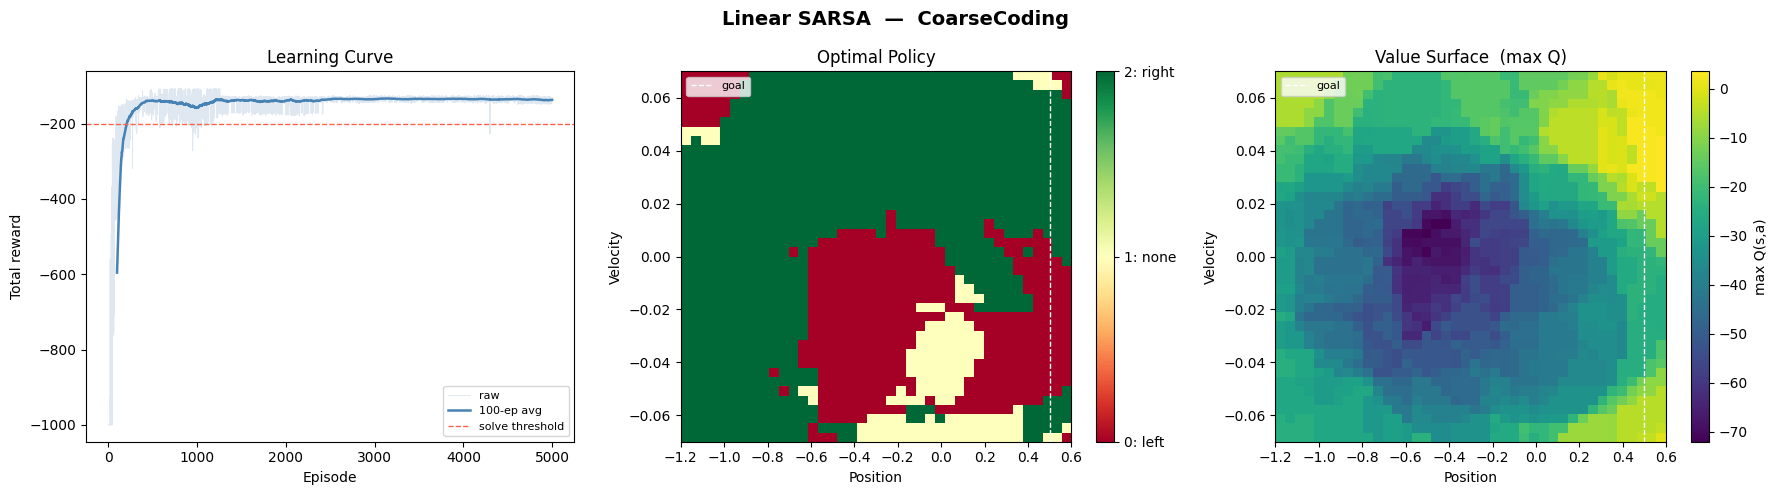

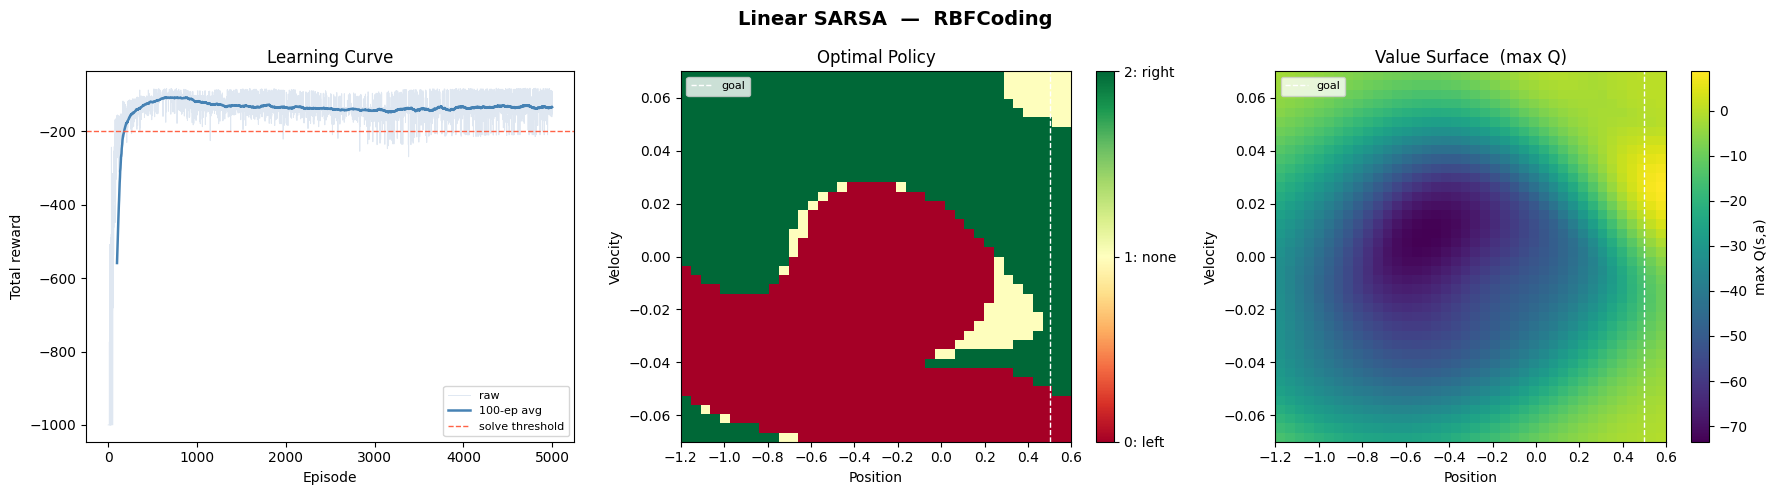

In [8]:
plot_results(agent_cc)   # coarse coding plots
plot_results(agent_rbf)  # RBF plots

# LSPI-TD in chain walk

In [9]:
import numpy as np

class ChainWalk:
    """
    A simple 1D Chain Walk environment.
    States are 0, 1, ..., num_states-1.
    Actions: 0 (Left), 1 (Right).
    """
    def __init__(self, num_states=4, reward_states=[0, 3], reward_val=1.0):
        self.num_states = num_states
        self.reward_states = set(reward_states)
        self.reward_val = reward_val
        self.reset()

    def reset(self):
        self.state = np.random.randint(0, self.num_states)
        return self.state

    def step(self, action):
        # 90% success rate to move in chosen direction, 10% to move opposite
        if np.random.rand() < 0.1:
            actual_action = 1 - action
        else:
            actual_action = action

        # Update state
        if actual_action == 0:  # Left
            next_state = max(0, self.state - 1)
        else:  # Right
            next_state = min(self.num_states - 1, self.state + 1)

        self.state = next_state

        # Calculate reward
        reward = self.reward_val if next_state in self.reward_states else 0.0
        return next_state, reward

    def generate_dataset(self, num_samples=1000):
        """Generates a dataset D consisting of (s, a, r, s') tuples."""
        dataset = []
        self.reset()
        for _ in range(num_samples):
            s = self.state
            a = np.random.randint(0, 2)
            s_next, r = self.step(a)
            dataset.append((s, a, r, s_next))

            # Periodically reset to ensure good state coverage
            if np.random.rand() < 0.1:
                self.reset()
        return dataset

In [10]:
class LSPITD:
    """
    Least-Squares Policy Iteration (LSPI) using LSTDQ for policy evaluation.
    """
    def __init__(self, num_states, num_actions, gamma=0.9, epsilon=1e-4):
        self.num_states = num_states
        self.num_actions = num_actions
        self.gamma = gamma
        self.epsilon = epsilon

        # Total features = state features * num_actions (Tabular-like feature mapping)
        self.num_features = self.num_states * self.num_actions

        # Initialize policy: default action is 0 (Left) for all states
        self.policy = np.zeros(self.num_states, dtype=int)

    def _get_features(self, state, action):
        """Returns a feature vector for a given state-action pair."""
        phi = np.zeros(self.num_features)
        idx = state * self.num_actions + action
        phi[idx] = 1.0
        return phi

    def lstdq(self, dataset):
        """Evaluates the current policy using LSTDQ to find Q-value weights."""
        k = self.num_features
        A = np.zeros((k, k))
        b = np.zeros(k)

        # Small regularization term to ensure invertibility
        A += np.eye(k) * 1e-6

        for s, a, r, s_next in dataset:
            phi_sa = self._get_features(s, a)

            # Choose next action greedily according to current policy
            a_next = self.policy[s_next]
            phi_s_next_a_next = self._get_features(s_next, a_next)

            # Outer product updates for A and b matrix
            A += np.outer(phi_sa, phi_sa - self.gamma * phi_s_next_a_next)
            b += phi_sa * r

        # Solve for the weights w (Q = phi^T * w)
        w = np.linalg.solve(A, b)
        return w

    def train(self, dataset, max_iterations=20):
        """Runs the LSPI-TD outer loop until the policy converges."""
        for i in range(max_iterations):
            # 1. Policy Evaluation via LSTDQ
            w = self.lstdq(dataset)

            # 2. Policy Improvement (argmax over Q-values)
            policy_changed = False
            for s in range(self.num_states):
                q_values = []
                for a in range(self.num_actions):
                    phi = self._get_features(s, a)
                    q_values.append(np.dot(phi, w))

                best_action = np.argmax(q_values)

                if best_action != self.policy[s]:
                    self.policy[s] = best_action
                    policy_changed = True

            print(f"Iteration {i+1}: Current Policy -> {self.policy}")

            # Terminate loop if the policy stops changing (π ≈ π')
            if not policy_changed:
                print("Policy converged!")
                break

        return self.policy


In [11]:
NUM_STATE = 50
REWARD_STATES =[10, 41]

env = ChainWalk(num_states=NUM_STATE, reward_states=REWARD_STATES)
dataset = env.generate_dataset(num_samples=2000)

# Initialize and run LSPI-TD
lspi = LSPITD(num_states=NUM_STATE, num_actions=2, gamma=0.9)
optimal_policy = lspi.train(dataset)

print(f"\nFinal learned policy mapping (0=Left, 1=Right): {optimal_policy}")

Iteration 1: Current Policy -> [0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 1 0 0 0 0 0 0 0 0]
Iteration 2: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 3: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 4: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 5: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 6: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]


Iteration 7: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 8: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 9: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 10: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 11: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Iteration 12: Current Policy -> [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]
Policy converged!

Final learned policy mapping (0=Left, 1=Right): [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0]


## Lecture 7: Policy Gradient Methods

Learning a parameterised policy directly, rather than deriving it from a value function.

## Policy-Based Reinforcement Learning
$$\pi_{\theta}(s, a) = \mathbb{P}[a \mid s, \theta]$$
measuring the quality of a policy $\pi_\theta$:
* In episodic environments we can use the start value

$$J_1(\theta) = V^{\pi_\theta}(s_1) = \mathbb{E}_{\pi_\theta} [v_1]$$

* In continuing environments we can use the average value

$$J_{avV}(\theta) = \sum_{s} d^{\pi_\theta}(s)V^{\pi_\theta}(s)$$

* Or the average reward per time-step

$$J_{avR}(\theta) = \sum_{s} d^{\pi_\theta}(s)\sum_{a} \pi_\theta(s, a)\mathcal{R}_s^a$$

* where $d^{\pi_\theta}(s)$ is stationary distribution of Markov chain for $\pi_\theta$

### Policy Gradient
searching for local max in J(θ) by ascending the gradient of the policy, w.r.t. parameters θ:

$$\Delta \theta = \alpha \nabla_{\theta} J(\theta)$$

* Where $\nabla_{\theta} J(\theta)$ is the policy gradient

$$\nabla_{\theta} J(\theta) = \begin{pmatrix} \frac{\partial J(\theta)}{\partial \theta_1} \\ \vdots \\ \frac{\partial J(\theta)}{\partial \theta_n} \end{pmatrix}$$

* and $\alpha$ is a step-size parameter

---
## Score Function
**Likelihood ratios** exploit the following identity

$$\begin{aligned}
\nabla_{\theta}\pi_{\theta}(s, a) &= \pi_{\theta}(s, a) \frac{\nabla_{\theta}\pi_{\theta}(s, a)}{\pi_{\theta}(s, a)} \\
&= \pi_{\theta}(s, a) \nabla_{\theta} \log \pi_{\theta}(s, a)
\end{aligned}$$

**The score** function is $\nabla_{\theta} \log \pi_{\theta}(s, a)$

### Softmax Policy
Weight actions using linear combination of features $\phi(s, a)^\top \theta$

 Probability of action is proportional to exponentiated weight

$$\pi_{\theta}(s, a) \propto e^{\phi(s, a)^\top \theta}$$

 The score function is

$$\nabla_{\theta} \log \pi_{\theta}(s, a) = \phi(s, a) - \mathbb{E}_{\pi_{\theta}} [\phi(s, \cdot)]$$

### Gaussian Policy

In continuous action spaces, a Gaussian policy is natural

Mean is a linear combination of state features $\mu(s) = \phi(s)^\top \theta$

Variance may be fixed $\sigma^2$, or can also parametrised

Policy is Gaussian, $a \sim \mathcal{N}(\mu(s), \sigma^2)$

The score function is

$$\nabla_{\theta} \log \pi_{\theta}(s, a) = \frac{(a - \mu(s))\phi(s)}{\sigma^2}$$
The Gaussian policy learns by:

shifting its mean toward actions that worked well

---
## Policy Gradient Theorem
For any differentiable policy $\pi_\theta(s, a)$,
for any of the policy objective functions $J = J_1, J_{avR}$, or $\frac{1}{1-\gamma}J_{avV}$,
the policy gradient is

$$\nabla_{\theta}J(\theta) = \mathbb{E}_{\pi_{\theta}} \left[ \nabla_{\theta} \log \pi_{\theta}(s, a) Q^{\pi_\theta}(s, a) \right]$$

---
## Monte-Carlo Policy Gradient (REINFORCE)
 Using return $v_t$ as an unbiased sample of $Q^{\pi_\theta}(s_t, a_t)$

$$\Delta\theta_t = \alpha\nabla_{\theta}\log\pi_{\theta}(s_t, a_t)v_t$$

**function** REINFORCE

$\quad$ Initialise $\theta$ arbitrarily

$\quad$ **for** each episode $\{s_1, a_1, r_2, \dots, s_{T-1}, a_{T-1}, r_T\} \sim \pi_\theta$ **do**

$\quad\quad$ **for** $t = 1$ to $T - 1$ **do**


$$\theta \leftarrow \theta + \alpha\nabla_{\theta}\log\pi_{\theta}(s_t, a_t)v_t$$

$\quad\quad$ **end for**

$\quad$ **end for**

$\quad$ **return** $\theta$

**end function**

---
## Actor-critic

Actor-critic algorithms maintain *two* sets of parameters
* **Critic** Updates action-value function parameters $w$
* **Actor** Updates policy parameters $\theta$, in direction suggested by critic


Actor-critic algorithms follow an *approximate* policy gradient

$$\nabla_{\theta}J(\theta) \approx \mathbb{E}_{\pi_{\theta}} \left[ \nabla_{\theta} \log \pi_{\theta}(s, a) Q_w(s, a) \right]$$

$$\Delta\theta = \alpha\nabla_{\theta} \log \pi_{\theta}(s, a) Q_w(s, a)$$


### Action-Value Actor-Critic

* Using linear value fn approx. $Q_w(s, a) = \phi(s, a)^\top w$
* Critic Updates $w$ by linear TD(0)
* Actor Updates $\theta$ by policy gradient



## **function** QAC

$\quad$ Initialise $s, \theta$

$\quad$ Sample $a \sim \pi_\theta$

$\quad$ **for** each step **do**

$\quad\quad$ Sample reward $r = \mathcal{R}_s^a$; sample transition $s' \sim \mathcal{P}_{s, \cdot}^a$

$\quad\quad$ Sample action $a' \sim \pi_\theta(s', a')$

$\quad\quad$ $\delta = r + \gamma Q_w(s', a') - Q_w(s, a)$

$\quad\quad$ $\theta = \theta + \alpha \nabla_\theta \log \pi_\theta(s, a) Q_w(s, a)$

$\quad\quad$ $w \leftarrow w + \beta \delta \phi(s, a)$

$\quad\quad$ $a \leftarrow a', s \leftarrow s'$

$\quad$ **end for**

**end function**

---
### Theorem (Compatible Function Approximation Theorem)

If the following two conditions are satisfied:

1 Value function approximator is *compatible* to the policy

$$\nabla_w Q_w(s, a) = \nabla_\theta \log \pi_\theta(s, a)$$

2 Value function parameters $w$ minimise the mean-squared error

$$\varepsilon = \mathbb{E}_{\pi_\theta} \left[ \left( Q^{\pi_\theta}(s, a) - Q_w(s, a) \right)^2 \right]$$

Then the policy gradient is exact,

$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) Q_w(s, a) \right]$$

### ⟹ Reducing Variance Using a Baseline
This can reduce variance, without changing expectation
* A good baseline is the state value function $B(s) = V^{\pi_\theta}(s)$
* So we can rewrite the policy gradient using the advantage function $A^{\pi_\theta}(s, a)$

$$A^{\pi_\theta}(s, a) = Q^{\pi_\theta}(s, a) - V^{\pi_\theta}(s)$$

$$\nabla_{\theta}J(\theta) = \mathbb{E}_{\pi_{\theta}} \left[ \nabla_{\theta} \log \pi_{\theta}(s, a) A^{\pi_\theta}(s, a) \right]$$

\\


For the true value function $V^{\pi_\theta}(s)$, the TD error $\delta^{\pi_\theta}$

$$\delta^{\pi_\theta} = r + \gamma V^{\pi_\theta}(s') - V^{\pi_\theta}(s)$$

* So we can use the TD error to compute the policy gradient

$$\nabla_{\theta}J(\theta) = \mathbb{E}_{\pi_{\theta}} \left[ \nabla_{\theta} \log \pi_{\theta}(s, a) \, \delta^{\pi_\theta} \right]$$

* In practice we can use an approximate TD error

$$\delta_v = r + \gamma V_v(s') - V_v(s)$$

\\

\\


Critics at Different Time-Scales (policy evaluation)

* For MC, the target is the return $v_t$
$$\Delta\theta = \alpha(v_t - V_\theta(s))\phi(s)$$

* For $\text{TD}(0)$, the target is the TD target $r + \gamma V(s')$
$$\Delta\theta = \alpha(r + \gamma V(s') - V_\theta(s))\phi(s)$$

* For forward-view $\text{TD}(\lambda)$, the target is the $\lambda$-return $v_t^\lambda$
$$\Delta\theta = \alpha(v_t^\lambda - V_\theta(s))\phi(s)$$

* For backward-view $\text{TD}(\lambda)$, we use eligibility traces
$$\delta_t = r_{t+1} + \gamma V(s_{t+1}) - V(s_t)$$
$$e_t = \gamma\lambda e_{t-1} + \phi(s_t)$$
$$\Delta\theta = \alpha\delta_t e_t$$

---
standard policy gradient (vanilla gradient) : θ ← θ+α∇θ​J(θ
⟹ This gradient depends on how we parameterize the policy

the solution:
## Natural Policy Gradient

The natural policy gradient is parametrisation independent
* It finds ascent direction that is closest to vanilla gradient, when changing policy by a small, fixed amount

$$\nabla_\theta^{nat} \pi_\theta(s, a) = G_\theta^{-1} \nabla_\theta \pi_\theta(s, a)$$

* where $G_\theta$ is the Fisher information matrix

$$G_\theta = \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) \nabla_\theta \log \pi_\theta(s, a)^T \right]$$

Why it's “parameterization independent”

Because it depends on: The distribution $\pi_{\theta}$ & Not the specific way θ represents it
	​

So if you reparameterize the model:

Vanilla gradient changes ❌

Natural gradient stays consistent ✅

# Summary of Policy Gradient Algorithms

$$
\begin{aligned}
\nabla_\theta J(\theta) &= \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) v_t \right] & \text{REINFORCE} \\
&= \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) Q^w(s, a) \right] & \text{Q Actor-Critic} \\
&= \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) A^w(s, a) \right] & \text{Advantage Actor-Critic} \\
&= \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) \delta \right] & \text{TD Actor-Critic} \\
&= \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(s, a) \delta e \right] & \text{TD}(\lambda) \text{Actor-Critic} \\
G_\theta^{-1} \nabla_\theta J(\theta) &= w & \text{Natural Actor-Critic}
\end{aligned}
$$


# puck world : Monte Carlo Policy Gradient (REINFORCE)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────────────────────
# 1.  PUCKWORLD ENVIRONMENT  (fixed)
# ─────────────────────────────────────────────────────────────────────────────

class PuckWorld:
    """
    Continuous 2-D arena.  State = [px, py, pvx, pvy, tx, ty].
    Actions: 0=Up  1=Down  2=Left  3=Right.

    Changes from original
    ---------------------
    * _get_state() normalises velocity features so all dims ∈ [−1, 1].
    * step() clips velocity to ±max_vel after physics update.
    """

    def __init__(self, arena_size=1.0, target_radius=0.1, dt=0.1,
                 accel=0.02, damping=0.95):
        self.arena_size    = arena_size
        self.target_radius = target_radius
        self.dt            = dt
        self.accel         = accel
        self.damping       = damping
        # FIX 4 & 5: compute terminal velocity for normalisation + clipping
        self.max_vel       = accel / (1.0 - damping)   # = 0.02/0.05 = 0.4
        self.reset()

    def reset(self):
        self.px  = np.random.uniform(0, self.arena_size)
        self.py  = np.random.uniform(0, self.arena_size)
        self.pvx = 0.0
        self.pvy = 0.0
        self._relocate_target()
        self.elapsed_time = 0.0
        return self._get_state()

    def _relocate_target(self):
        self.tx = np.random.uniform(0, self.arena_size)
        self.ty = np.random.uniform(0, self.arena_size)

    def _get_state(self):
        # FIX 4: normalise velocity so all features live in [0,1] or [−1,1]
        return np.array([
            self.px  / self.arena_size,
            self.py  / self.arena_size,
            self.pvx / self.max_vel,        # ← normalised
            self.pvy / self.max_vel,        # ← normalised
            self.tx  / self.arena_size,
            self.ty  / self.arena_size,
        ], dtype=np.float32)

    def step(self, action):
        self.elapsed_time += self.dt
        if self.elapsed_time >= 30.0:
            self._relocate_target()
            self.elapsed_time = 0.0

        if   action == 0: self.pvy += self.accel   # Up
        elif action == 1: self.pvy -= self.accel   # Down
        elif action == 2: self.pvx -= self.accel   # Left
        elif action == 3: self.pvx += self.accel   # Right

        self.px  += self.pvx
        self.py  += self.pvy
        self.pvx *= self.damping
        self.pvy *= self.damping

        # FIX 5: clip velocity
        self.pvx = np.clip(self.pvx, -self.max_vel, self.max_vel)
        self.pvy = np.clip(self.pvy, -self.max_vel, self.max_vel)

        self.px = np.clip(self.px, 0, self.arena_size)
        self.py = np.clip(self.py, 0, self.arena_size)

        dist   = np.hypot(self.px - self.tx, self.py - self.ty)
        reward = -dist
        if dist < self.target_radius:
            reward += 1.0

        return self._get_state(), reward, False

In [13]:
class REINFORCE:
    """
    Monte Carlo Policy Gradient with softmax linear policy.
    π(a|s) = softmax(θ · s)

    Changes from original
    ---------------------
    * update_theta() subtracts a mean baseline from returns.      (FIX 1)
    * update_theta() normalises returns to unit variance.          (FIX 2)
    * train() returns episode reward history for plotting.         (FIX 3)
    """

    def __init__(self, num_states, num_actions, alpha=0.01, gamma=0.99):
        self.num_states  = num_states
        self.num_actions = num_actions
        self.alpha       = alpha
        self.gamma       = gamma
        self.theta       = np.zeros((num_actions, num_states), dtype=np.float32)

        self.states  = []
        self.actions = []
        self.rewards = []

    # ── policy ────────────────────────────────────────────────────────────────

    def get_action_probs(self, state):
        prefs = self.theta @ state
        prefs -= prefs.max()                    # numerical stability
        exp   = np.exp(prefs)
        return exp / exp.sum()

    def choose_action(self, state):
        return int(np.random.choice(self.num_actions, p=self.get_action_probs(state)))

    # ── memory ────────────────────────────────────────────────────────────────

    def store_transition(self, state, action, reward):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)

    # ── update ────────────────────────────────────────────────────────────────

    def update_theta(self):
        T = len(self.rewards)

        # Step 1: discounted returns
        G, returns = 0.0, np.zeros(T)
        for t in reversed(range(T)):
            G         = self.rewards[t] + self.gamma * G
            returns[t] = G

        # FIX 1 & 2: baseline + normalisation → lower variance, stable updates
        returns -= returns.mean()
        std      = returns.std()
        if std > 1e-8:
            returns /= std

        # Step 2: gradient ascent
        for t in range(T):
            state  = self.states[t]
            action = self.actions[t]
            G_t    = returns[t]

            probs        = self.get_action_probs(state)
            grad         = -probs.copy()
            grad[action] += 1.0                 # ∇ log π(a|s)

            discount      = self.gamma ** t
            self.theta   += self.alpha * discount * G_t * np.outer(grad, state)

        self.states, self.actions, self.rewards = [], [], []

    # ── training loop ─────────────────────────────────────────────────────────

    def train(self, env, num_episodes=500, max_steps=200, print_every=50):
        """
        FIX 3: returns episode_rewards list for plotting.
        """
        episode_rewards = []

        for ep in range(num_episodes):
            state        = env.reset()
            total_reward = 0.0

            for _ in range(max_steps):
                action               = self.choose_action(state)
                next_state, r, done  = env.step(action)
                self.store_transition(state, action, r)
                state        = next_state
                total_reward += r
                if done:
                    break

            self.update_theta()
            episode_rewards.append(total_reward)

            if (ep + 1) % print_every == 0:
                avg = np.mean(episode_rewards[-print_every:])
                print(f"Episode {ep+1:4d}/{num_episodes}  "
                      f"Return: {total_reward:8.2f}  "
                      f"Avg-{print_every}: {avg:8.2f}")

        return episode_rewards

    def rollout(self, env, max_steps=300):
        """Run one greedy episode and return trajectory for visualisation."""
        state = env.reset()
        traj  = {"px": [], "py": [], "tx": [], "ty": [], "rewards": []}

        for _ in range(max_steps):
            # store raw positions before they are normalised
            traj["px"].append(env.px)
            traj["py"].append(env.py)
            traj["tx"].append(env.tx)
            traj["ty"].append(env.ty)

            action              = self.choose_action(state)
            state, reward, done = env.step(action)
            traj["rewards"].append(reward)
            if done:
                break

        return traj


In [14]:
def plot_learning_curve(episode_rewards, window=20):
    """Smoothed return curve with raw returns in the background."""
    fig, ax = plt.subplots(figsize=(9, 4))
    eps = np.arange(1, len(episode_rewards) + 1)

    ax.plot(eps, episode_rewards, color="#B5D4F4", lw=0.8, alpha=0.6, label="Episode return")

    # smoothed
    if len(episode_rewards) >= window:
        smoothed = np.convolve(episode_rewards,
                               np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window, len(episode_rewards) + 1),
                smoothed, color="#378ADD", lw=2, label=f"{window}-ep moving avg")

    ax.axhline(0, color="gray", lw=0.7, ls=":")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total return")
    ax.set_title("REINFORCE learning curve — PuckWorld")
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig("learning_curve.png", dpi=150)
    plt.show()


def plot_trajectory(traj, arena_size=1.0, target_radius=0.1):
    """Static plot of one rollout: puck path + target positions."""
    fig, ax = plt.subplots(figsize=(6, 6))

    px = np.array(traj["px"])
    py = np.array(traj["py"])
    tx = np.array(traj["tx"])
    ty = np.array(traj["ty"])

    # colour path by cumulative reward
    rewards = np.array(traj["rewards"])
    cum_r   = np.cumsum(rewards)
    norm    = plt.Normalize(cum_r.min(), cum_r.max())
    cmap    = plt.cm.RdYlGn

    for i in range(len(px) - 1):
        ax.plot(px[i:i+2], py[i:i+2],
                color=cmap(norm(cum_r[i])), lw=1.5, alpha=0.8)

    # target circle(s) — draw unique positions
    seen = set()
    for x, y in zip(tx, ty):
        key = (round(x, 3), round(y, 3))
        if key not in seen:
            circle = mpatches.Circle((x, y), target_radius,
                                     color="#1D9E75", alpha=0.25)
            ax.add_patch(circle)
            ax.plot(x, y, "x", color="#1D9E75", ms=8, mew=2)
            seen.add(key)

    # start / end markers
    ax.plot(px[0],  py[0],  "o", color="#378ADD", ms=10, label="Start",  zorder=5)
    ax.plot(px[-1], py[-1], "s", color="#D85A30", ms=10, label="End",    zorder=5)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Cumulative reward")

    ax.set_xlim(0, arena_size)
    ax.set_ylim(0, arena_size)
    ax.set_aspect("equal")
    ax.set_title("Learned policy — single rollout")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig("trajectory.png", dpi=150)
    plt.show()

Training REINFORCE on PuckWorld …



Episode  100/7000  Return:   -94.95  Avg-100:  -120.07


Episode  200/7000  Return:   -86.79  Avg-100:  -102.16


Episode  300/7000  Return:   -53.67  Avg-100:   -97.32


Episode  400/7000  Return:   -87.25  Avg-100:   -89.40


...

Episode 6600/7000  Return:    11.14  Avg-100:    14.01


Episode 6700/7000  Return:   -18.16  Avg-100:    17.47


Episode 6800/7000  Return:    -7.68  Avg-100:    25.24


Episode 6900/7000  Return:    71.17  Avg-100:    23.35


Episode 7000/7000  Return:   -14.15  Avg-100:    23.87


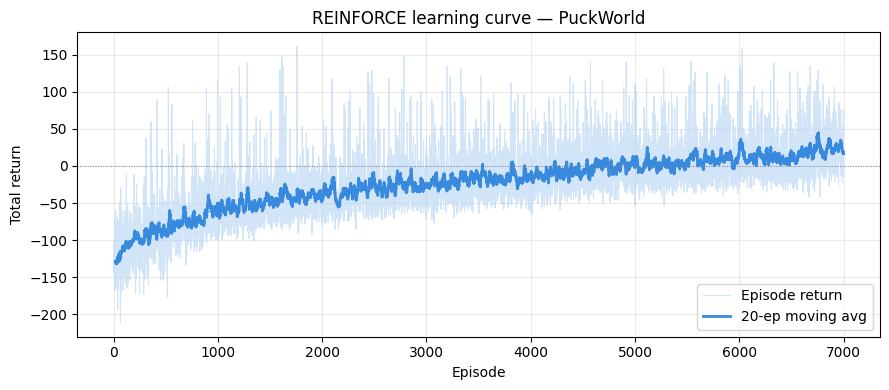

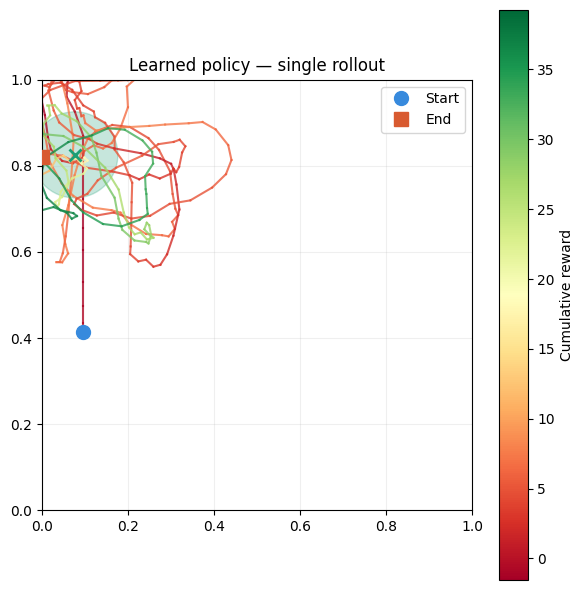

In [15]:
np.random.seed(0)

env   = PuckWorld(arena_size=1.0, target_radius=0.1, dt=0.1)
agent = REINFORCE(num_states=6, num_actions=4, alpha=0.005, gamma=0.99)

print("Training REINFORCE on PuckWorld …\n")
rewards = agent.train(env, num_episodes=7000, max_steps=200, print_every=100)

plot_learning_curve(rewards, window=20)

traj = agent.rollout(env, max_steps=300)
plot_trajectory(traj)


# QAC

In [16]:
import numpy as np

class QAC:
    def __init__(self, state_size, action_size, alpha=0.01, beta=0.05, gamma=0.99):
        self.state_size = state_size
        self.action_size = action_size
        self.alpha = alpha  # actor lr
        self.beta = beta    # critic lr
        self.gamma = gamma

        # Initialize parameters
        self.theta = np.zeros(state_size * action_size)  # actor
        self.w = np.zeros(state_size * action_size)      # critic

    def phi(self, state, action):
        """Feature vector phi(s, a) — one-hot tabular"""
        features = np.zeros(self.state_size * self.action_size)
        features[state * self.action_size + action] = 1.0
        return features

    def Q(self, state, action):
        """Q_w(s, a) = w^T * phi(s, a)"""
        return np.dot(self.w, self.phi(state, action))

    def policy(self, state):
        """Softmax policy pi_theta(s, .)"""
        prefs = np.array([
            np.dot(self.theta, self.phi(state, a))
            for a in range(self.action_size)
        ])
        prefs -= prefs.max()  # numerical stability
        exp_prefs = np.exp(prefs)
        return exp_prefs / exp_prefs.sum()

    def sample_action(self, state):
        """Sample a ~ pi_theta(s, .)"""
        probs = self.policy(state)
        return np.random.choice(self.action_size, p=probs)

    def score_function(self, state, action):
        """grad_theta log pi_theta(s, a) = phi(s,a) - E_pi[phi(s,.)]"""
        probs = self.policy(state)
        baseline = sum(probs[a] * self.phi(state, a) for a in range(self.action_size))
        return self.phi(state, action) - baseline

    def run(self, env, num_steps, log_every=100):
          s = env.reset()
          a = self.sample_action(s)

          episode_reward = 0
          episode = 1

          for step in range(num_steps):
              r, s_prime = env.step(s, a)
              a_prime = self.sample_action(s_prime)

              delta = r + self.gamma * self.Q(s_prime, a_prime) - self.Q(s, a)
              self.theta += self.alpha * self.score_function(s, a) * self.Q(s, a)
              self.w += self.beta * delta * self.phi(s, a)

              episode_reward += r

              if step % log_every == 0:
                  print(f"Step {step:4d} | Episode reward so far: {episode_reward:.2f} | "
                        f"Q(s,a): {self.Q(s, a):.4f}")

              s, a = s_prime, a_prime

          print("\n--- Final Policy ---")
          for state in range(self.state_size):
              probs = self.policy(state)
              best_action = np.argmax(probs)
              print(f"  State {state}: best action = {best_action}, probs = {np.round(probs, 3)}")

          print("\n--- Q values ---")
          for state in range(self.state_size):
              for action in range(self.action_size):
                  print(f"  Q({state}, {action}) = {self.Q(state, action):.4f}")


In [17]:
# Simple test environment
class SimpleEnv:
    def reset(self):
        return 0

    def step(self, state, action):
        next_state = min(state + action, 4)
        reward = 1.0 if next_state == 4 else 0.0
        return reward, next_state


In [18]:
env = SimpleEnv()
qac = QAC(state_size=5, action_size=2, alpha=0.01, beta=0.05, gamma=0.99)
qac.run(env, num_steps=1000)
print("Training complete.")

Step    0 | Episode reward so far: 0.00 | Q(s,a): 0.0000
Step  100 | Episode reward so far: 93.00 | Q(s,a): 2.3321
Step  200 | Episode reward so far: 193.00 | Q(s,a): 4.4827
Step  300 | Episode reward so far: 293.00 | Q(s,a): 7.0801
Step  400 | Episode reward so far: 393.00 | Q(s,a): 9.4656
Step  500 | Episode reward so far: 493.00 | Q(s,a): 11.9734
Step  600 | Episode reward so far: 593.00 | Q(s,a): 15.0803
Step  700 | Episode reward so far: 693.00 | Q(s,a): 16.6507
Step  800 | Episode reward so far: 793.00 | Q(s,a): 18.8489
Step  900 | Episode reward so far: 893.00 | Q(s,a): 22.4640

--- Final Policy ---
  State 0: best action = 0, probs = [0.5 0.5]
  State 1: best action = 0, probs = [0.5 0.5]
  State 2: best action = 0, probs = [0.5 0.5]
  State 3: best action = 0, probs = [0.5 0.5]
  State 4: best action = 0, probs = [0.966 0.034]

--- Q values ---
  Q(0, 0) = 0.0000
  Q(0, 1) = 0.0000
  Q(1, 0) = 0.0000
  Q(1, 1) = 0.0000
  Q(2, 0) = 0.0000
  Q(2, 1) = 0.0000
  Q(3, 0) = 0.0000
 

## Lecture 8: Integrating Learning and Planning

Learning a model of the environment from experience, then planning with it — the Dyna architecture.

# Model-Based Reinforcement Learning
Model-Based RL:
* Learn a model from experience
* Plan value function (and/or policy) from model

Model $\mathcal{M}_\eta$ Learning:
* Learning s, a → r is a regression problem
* Learning s, a → s' is a density estimation problem
* Pick loss function, e.g. mean-squared error, KL divergence, ...
* Find parameters $\eta$ that minimise empirical loss

Examples of Models:
* Table Lookup Model
* Linear Expectation Model
* Linear Gaussian Model
* Gaussian Process Model
* Deep Belief Network Model

---
## Planning with a Model

Given a model $\mathcal{M}_\eta = \langle \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$

Solve the MDP $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$

Using favourite planning algorithm
* Value iteration
* Policy iteration
* Tree search

### Sample-Based Planning
Use the model only to generate samples ,
Sample experience from model , Apply model-free RL to samples, e.g.:
* Monte-Carlo control
* Sarsa
* Q-learning

---
## Dyna
Real experience Sampled from environment (true MDP)

Simulated experience Sampled from model (approximate MDP)

Dyna :
Learn a model from real experience ,
Learn and plan value function (and/or policy) from **real** and
**simulated experience**

Dyna-Q Algorithm:

Initialize $Q(s,a)$ and $Model(s,a)$ for all $s \in \mathcal{S}$ and $a \in \mathcal{A}(s)$

Do forever:

$\quad$ (a) $S \leftarrow$ current (nonterminal) state

$\quad$ (b) $A \leftarrow \varepsilon\text{-greedy}(S, Q)$

$\quad$ (c) Execute action $A$; observe resultant reward, $R$, and state, $S'$

$\quad$ (d) $Q(S, A) \leftarrow Q(S, A) + \alpha\left[R + \gamma \max_{a} Q(S',a) - Q(S, A)\right]$

$\quad$ (e) $Model(S, A) \leftarrow R, S'$ (assuming deterministic environment)

$\quad$ (f) Repeat $n$ times:

$\quad\quad\quad S \leftarrow$ random previously observed state

$\quad\quad\quad A \leftarrow$ random action previously taken in $S$

$\quad\quad\quad R, S' \leftarrow Model(S, A)$

$\quad\quad\quad Q(S, A) \leftarrow Q(S, A) + \alpha\left[R + \gamma \max_{a} Q(S',a) - Q(S, A)\right]$

---
**Forward search** algorithms select the best action by lookahead , They build a search tree with the current state st at the root.

---
**Simulation-Based Search** Simulate episodes of experience from now with the model and Apply model-free RL to simulated episodes

* Monte-Carlo control ⟶ Monte-Carlo search

* Sarsa ⟶ TD search

---
## MCTS ( Monte-Carlo Tree Search )

Given a model $\mathcal{M}_v$ ,

Simulate K episodes from current state $s_t$ ,

Build a search tree containing visited states and actions

Evaluate states Q(s; a) by mean return of episodes from s, a

After search is finished, select current (real) action with maximum value in search tree

\\

Each simulation consists of two phases (in-tree, out-of-tree)

* Tree policy (improves): pick actions to maximise Q(S;A)

* Default policy (fixed): pick actions randomly

Repeat (each simulation)
* Evaluate states Q(S;A) by Monte-Carlo evaluation
* Improve tree policy, e.g. by ϵ-greedy(Q)

---
## Temporal-Difference Search

Using TD instead of MC , TD search applies Sarsa to sub-MDP from now

TD search is usually more efficient than MC search

TD(λ) search can be much more efficient than MC search

---
## Dyna-2
In Dyna-2, the agent stores two sets of feature weights
* Long-term memory
* Short-term (working) memory

Long-term memory is updated from real experience
* using TD learning
* General domain knowledge that applies to any episode

Short-term memory is updated from simulated experience
* using TD search
* Specific local knowledge about the current situation

Over value function is sum of long and short-term memories



# Dyna

In [19]:
import numpy as np
import random

class DynaQ:
    def __init__(self, state_size, action_size, alpha=0.1, gamma=0.99, epsilon=0.1, n=5):
        self.state_size = state_size
        self.action_size = action_size
        self.alpha = alpha      # learning rate
        self.gamma = gamma      # discount factor
        self.epsilon = epsilon  # exploration rate
        self.n = n              # planning steps

        # Initialize Q table and Model
        self.Q = np.zeros((state_size, action_size))
        self.model = {}         # model[(s, a)] = (r, s')
        self.observed = []      # list of (s, a) pairs seen so far

    def epsilon_greedy(self, state):
        """epsilon-greedy action selection"""
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        return np.argmax(self.Q[state])

    def q_update(self, s, a, r, s_prime):
        """Q(S,A) <- Q(S,A) + alpha * [R + gamma * max_a Q(S',a) - Q(S,A)]"""
        td_target = r + self.gamma * np.max(self.Q[s_prime])
        td_error = td_target - self.Q[s, a]
        self.Q[s, a] += self.alpha * td_error

    def run(self, env, num_steps, log_every=100):
        s = env.reset()
        total_reward = 0

        for step in range(num_steps):
            # (b) epsilon-greedy action
            a = self.epsilon_greedy(s)

            # (c) execute action
            r, s_prime = env.step(s, a)
            total_reward += r

            # (d) direct Q update
            self.q_update(s, a, r, s_prime)

            # (e) update model
            if (s, a) not in self.model:
                self.observed.append((s, a))
            self.model[(s, a)] = (r, s_prime)

            # (f) planning: repeat n times
            for _ in range(self.n):
                sim_s, sim_a = random.choice(self.observed)
                sim_r, sim_s_prime = self.model[(sim_s, sim_a)]
                self.q_update(sim_s, sim_a, sim_r, sim_s_prime)

            if step % log_every == 0:
                print(f"Step {step:4d} | Total reward: {total_reward:.2f} | "
                      f"Q(s,a): {self.Q[s, a]:.4f} | Model size: {len(self.model)}")

            s = s_prime


In [20]:
class DynaQPlus(DynaQ):
    def __init__(self, state_size, action_size, alpha=0.1, gamma=0.99,
                 epsilon=0.1, n=5, kappa=0.001):

        super().__init__(state_size, action_size, alpha, gamma, epsilon, n)
        self.kappa = kappa                          # exploration bonus weight

        # tau[s,a] = number of steps since (s,a) was last tried
        self.tau = np.zeros((state_size, action_size))

    def run(self, env, num_steps, log_every=100):
        s = env.reset()
        total_reward = 0

        for step in range(num_steps):
            a = self.epsilon_greedy(s)
            r, s_prime = env.step(s, a)
            total_reward += r

            # Direct Q update (no bonus on real experience)
            self.q_update(s, a, r, s_prime)

            # Update model
            if (s, a) not in self.model:
                self.observed.append((s, a))
            self.model[(s, a)] = (r, s_prime)

            # Increment all taus, reset visited
            self.tau += 1
            self.tau[s, a] = 0

            # Planning with exploration bonus: r + κ√τ
            for _ in range(self.n):
                sim_s, sim_a = random.choice(self.observed)
                sim_r, sim_s_prime = self.model[(sim_s, sim_a)]

                # Bonus encourages revisiting long-untried (s,a) pairs
                bonus = self.kappa * np.sqrt(self.tau[sim_s, sim_a])
                td_target = (sim_r + bonus) + self.gamma * np.max(self.Q[sim_s_prime])
                self.Q[sim_s, sim_a] += self.alpha * (td_target - self.Q[sim_s, sim_a])

            if step % log_every == 0:
                print(f"[DynaQ+] Step {step:4d} | Reward: {total_reward:.2f} | "
                      f"Max tau: {int(self.tau.max())}")

            s = s_prime

In [21]:
class DynaAC:
    def __init__(self, state_size, action_size, alpha=0.01, beta=0.05,
                 gamma=0.99, epsilon=0.1, n=5):
        self.state_size = state_size
        self.action_size = action_size
        self.alpha = alpha      # actor lr
        self.beta = beta        # critic lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.n = n

        # Actor and critic parameters
        self.theta = np.zeros(state_size * action_size)   # policy params
        self.w = np.zeros(state_size * action_size)       # value params

        self.model = {}
        self.observed = []

    def phi(self, state, action):
        """One-hot feature vector"""
        f = np.zeros(self.state_size * self.action_size)
        f[state * self.action_size + action] = 1.0
        return f

    def Q(self, state, action):
        """Q_w(s,a) = w^T phi(s,a)"""
        return np.dot(self.w, self.phi(state, action))

    def policy(self, state):
        """Softmax policy"""
        prefs = np.array([np.dot(self.theta, self.phi(state, a))
                          for a in range(self.action_size)])
        prefs -= prefs.max()
        exp_p = np.exp(prefs)
        return exp_p / exp_p.sum()

    def sample_action(self, state):
        probs = self.policy(state)
        return np.random.choice(self.action_size, p=probs)

    def score_function(self, state, action):
        """grad_theta log pi_theta(s,a)"""
        probs = self.policy(state)
        baseline = sum(probs[a] * self.phi(state, a) for a in range(self.action_size))
        return self.phi(state, action) - baseline

    def ac_update(self, s, a, r, s_prime):
        """One actor-critic update step"""
        a_prime = self.sample_action(s_prime)
        delta = r + self.gamma * self.Q(s_prime, a_prime) - self.Q(s, a)

        # Actor update
        self.theta += self.alpha * self.score_function(s, a) * self.Q(s, a)

        # Critic update
        self.w += self.beta * delta * self.phi(s, a)

    def run(self, env, num_steps, log_every=100):
        s = env.reset()
        total_reward = 0

        for step in range(num_steps):
            a = self.sample_action(s)
            r, s_prime = env.step(s, a)
            total_reward += r

            # Real experience update
            self.ac_update(s, a, r, s_prime)

            # Update model
            if (s, a) not in self.model:
                self.observed.append((s, a))
            self.model[(s, a)] = (r, s_prime)

            # Planning: replay past experience through actor-critic
            for _ in range(self.n):
                sim_s, sim_a = random.choice(self.observed)
                sim_r, sim_s_prime = self.model[(sim_s, sim_a)]
                self.ac_update(sim_s, sim_a, sim_r, sim_s_prime)

            if step % log_every == 0:
                print(f"[DynaAC] Step {step:4d} | Reward: {total_reward:.2f} | "
                      f"Q(s,a): {self.Q(s, a):.4f}")

            s = s_prime

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class Maze:
    """
    Simple grid maze environment.

    Legend:
        0 = free cell
        1 = wall
        2 = start
        3 = goal
    """

    def __init__(self, grid=None):
        if grid is not None:
            self.grid = np.array(grid)
        else:
            # Default 6x9 maze (Sutton & Barto style)
            self.grid = np.array([
                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 1, 1, 1, 1, 1, 1, 1, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0, 0],
            ])
            self.start = (5, 3)
            self.goal  = (0, 8)

        self.rows, self.cols = self.grid.shape
        self.state_size = self.rows * self.cols
        self.action_size = 4  # 0=up, 1=down, 2=left, 3=right

        self._actions = {
            0: (-1,  0),   # up
            1: ( 1,  0),   # down
            2: ( 0, -1),   # left
            3: ( 0,  1),   # right
        }
        self._action_labels = {0: "↑", 1: "↓", 2: "←", 3: "→"}

        self.agent = self.start

    # ── Conversion helpers ──────────────────────────────────────────

    def to_state(self, row, col):
        return row * self.cols + col

    def to_rc(self, state):
        return divmod(state, self.cols)

    # ── Environment interface ────────────────────────────────────────

    def reset(self):
        self.agent = self.start
        return self.to_state(*self.agent)

    def step(self, state, action):
        row, col = self.to_rc(state)
        dr, dc = self._actions[action]
        new_row = np.clip(row + dr, 0, self.rows - 1)
        new_col = np.clip(col + dc, 0, self.cols - 1)

        # Hit a wall → stay in place
        if self.grid[new_row, new_col] == 1:
            new_row, new_col = row, col

        next_state = self.to_state(new_row, new_col)
        reward = 1.0 if (new_row, new_col) == self.goal else 0.0
        return reward, next_state

    # ── Visualization ────────────────────────────────────────────────

    def show(self, Q=None, path=None, title="Maze"):
        """
        Display the maze.
        - Q      : Q-table (state x action) → shows best action arrows
        - path   : list of states → draws the agent's trajectory
        - title  : plot title
        """
        fig, ax = plt.subplots(figsize=(self.cols * 0.9, self.rows * 0.9))
        ax.set_xlim(0, self.cols)
        ax.set_ylim(0, self.rows)
        ax.set_aspect("equal")
        ax.axis("off")
        ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

        for r in range(self.rows):
            for c in range(self.cols):
                # Flip row so row-0 is at top
                draw_r = self.rows - 1 - r

                if self.grid[r, c] == 1:
                    color = "#2c2c2c"
                elif (r, c) == self.goal:
                    color = "#4caf50"
                elif (r, c) == self.start:
                    color = "#2196f3"
                else:
                    color = "#f5f5f5"

                rect = patches.Rectangle(
                    (c, draw_r), 1, 1,
                    linewidth=0.5, edgecolor="#aaaaaa", facecolor=color
                )
                ax.add_patch(rect)

                # Labels for start / goal
                if (r, c) == self.goal:
                    ax.text(c + 0.5, draw_r + 0.5, "G",
                            ha="center", va="center",
                            fontsize=12, fontweight="bold", color="white")
                elif (r, c) == self.start:
                    ax.text(c + 0.5, draw_r + 0.5, "S",
                            ha="center", va="center",
                            fontsize=12, fontweight="bold", color="white")

                # Best action arrow from Q table
                elif Q is not None and self.grid[r, c] == 0:
                    s = self.to_state(r, c)
                    best_a = np.argmax(Q[s])
                    ax.text(c + 0.5, draw_r + 0.5,
                            self._action_labels[best_a],
                            ha="center", va="center",
                            fontsize=11, color="#555555")

        # Draw path
        if path is not None:
            path_rc = [self.to_rc(s) for s in path]
            xs = [c + 0.5 for r, c in path_rc]
            ys = [self.rows - 1 - r + 0.5 for r, c in path_rc]
            ax.plot(xs, ys, color="#e53935", linewidth=2,
                    marker="o", markersize=4, zorder=5)

        plt.tight_layout()
        plt.show()

    def get_path(self, Q):
        """Greedy rollout from start to goal (max 500 steps)"""
        s = self.reset()
        path = [s]
        for _ in range(500):
            a = np.argmax(Q[s])
            r, s = self.step(s, a)
            path.append(s)
            if r == 1.0:
                break
        return path



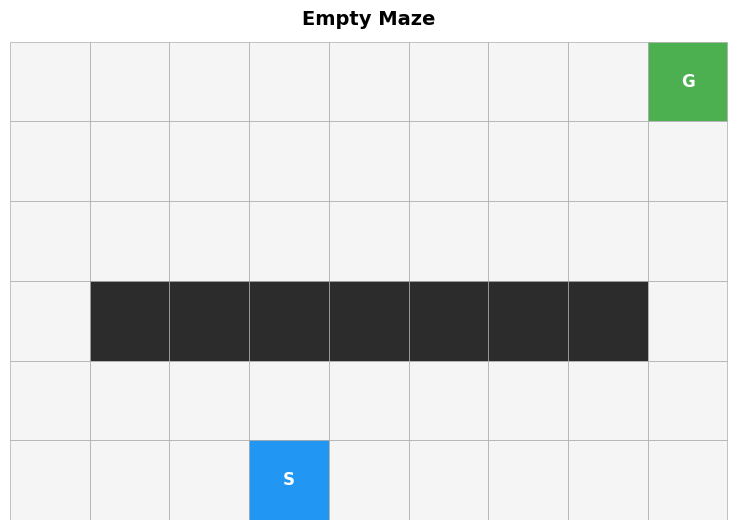

Step    0 | Total reward: 0.00 | Q(s,a): 0.0000 | Model size: 1
Step  500 | Total reward: 41.00 | Q(s,a): 3.7154 | Model size: 56


Step 1000 | Total reward: 488.00 | Q(s,a): 18.4009 | Model size: 60
Step 1500 | Total reward: 948.00 | Q(s,a): 19.8649 | Model size: 62
Step 2000 | Total reward: 1398.00 | Q(s,a): 19.9876 | Model size: 62
Step 2500 | Total reward: 1845.00 | Q(s,a): 19.9988 | Model size: 63


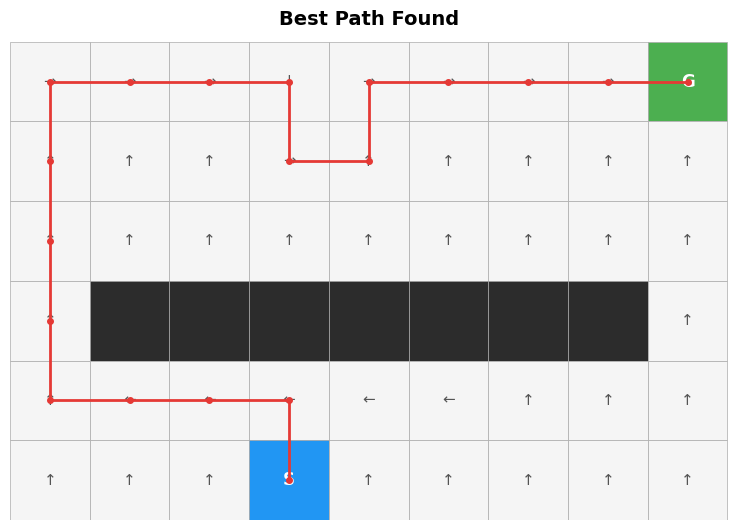

In [23]:
maze = Maze()


maze.show(title="Empty Maze")


agent = DynaQ(
      state_size=maze.state_size,
      action_size=maze.action_size,
      alpha=0.1, gamma=0.95, epsilon=0.15, n=10
)
agent.run(maze, num_steps=3000, log_every=500)


path = maze.get_path(agent.Q)
maze.show(Q=agent.Q, path=path, title="Best Path Found")

In [24]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

# ─────────────────────────────────────────────────────────────
# Maze Environment (Dynamic: wall shifts mid-training)
# ─────────────────────────────────────────────────────────────
class DynamicMaze:
    def __init__(self):
        # Phase 1 grid
        self.grid_phase1 = np.array([
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 1, 1, 1, 1, 1, 1, 1],
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
        ])
        # Phase 2: wall shifts (opens a gap on right, blocks on left)
        self.grid_phase2 = np.array([
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
            [1, 1, 1, 1, 1, 1, 1, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0],
        ])
        self.start = (5, 3)
        self.goal  = (0, 8)
        self.rows, self.cols = 6, 9
        self.state_size  = self.rows * self.cols
        self.action_size = 4
        self._actions = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
        self.grid = self.grid_phase1.copy()
        self.phase = 1

    def switch_phase(self):
        self.grid = self.grid_phase2.copy()
        self.phase = 2

    def to_state(self, r, c): return r * self.cols + c
    def to_rc(self, s): return divmod(s, self.cols)

    def reset(self):
        return self.to_state(*self.start)

    def step(self, state, action):
        r, c = self.to_rc(state)
        dr, dc = self._actions[action]
        nr = np.clip(r + dr, 0, self.rows - 1)
        nc = np.clip(c + dc, 0, self.cols - 1)
        if self.grid[nr, nc] == 1:
            nr, nc = r, c
        ns = self.to_state(nr, nc)
        reward = 1.0 if (nr, nc) == self.goal else 0.0
        return reward, ns

    def show(self, Q=None, path=None, title="Maze", ax=None):
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(self.cols * 0.85, self.rows * 0.85))
        ax.set_xlim(0, self.cols); ax.set_ylim(0, self.rows)
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_title(title, fontsize=12, fontweight="bold")
        labels = {0:"↑", 1:"↓", 2:"←", 3:"→"}
        for r in range(self.rows):
            for c in range(self.cols):
                dr = self.rows - 1 - r
                if self.grid[r, c] == 1:   color = "#2c2c2c"
                elif (r,c) == self.goal:   color = "#4caf50"
                elif (r,c) == self.start:  color = "#2196f3"
                else:                      color = "#f5f5f5"
                ax.add_patch(patches.Rectangle((c, dr), 1, 1,
                    linewidth=0.5, edgecolor="#aaaaaa", facecolor=color))
                if (r,c) == self.goal:
                    ax.text(c+.5, dr+.5, "G", ha="center", va="center",
                            fontsize=11, fontweight="bold", color="white")
                elif (r,c) == self.start:
                    ax.text(c+.5, dr+.5, "S", ha="center", va="center",
                            fontsize=11, fontweight="bold", color="white")
                elif Q is not None and self.grid[r,c] == 0:
                    s = self.to_state(r, c)
                    ax.text(c+.5, dr+.5, labels[np.argmax(Q[s])],
                            ha="center", va="center", fontsize=10, color="#555")
        if path:
            rcs = [self.to_rc(s) for s in path]
            xs = [c+.5 for r,c in rcs]; ys = [self.rows-1-r+.5 for r,c in rcs]
            ax.plot(xs, ys, color="#e53935", lw=2, marker="o", markersize=3, zorder=5)
        if standalone:
            plt.tight_layout(); plt.show()

    def get_path(self, Q, max_steps=200):
        s = self.reset(); path = [s]
        for _ in range(max_steps):
            r, s = self.step(s, np.argmax(Q[s]))
            path.append(s)
            if r == 1.0: break
        return path


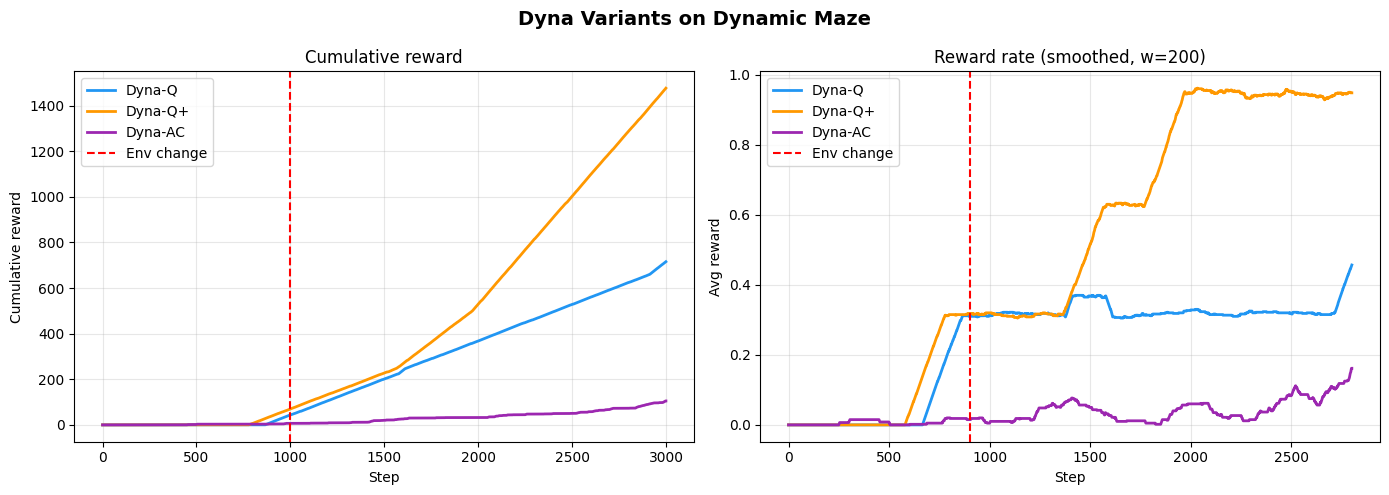

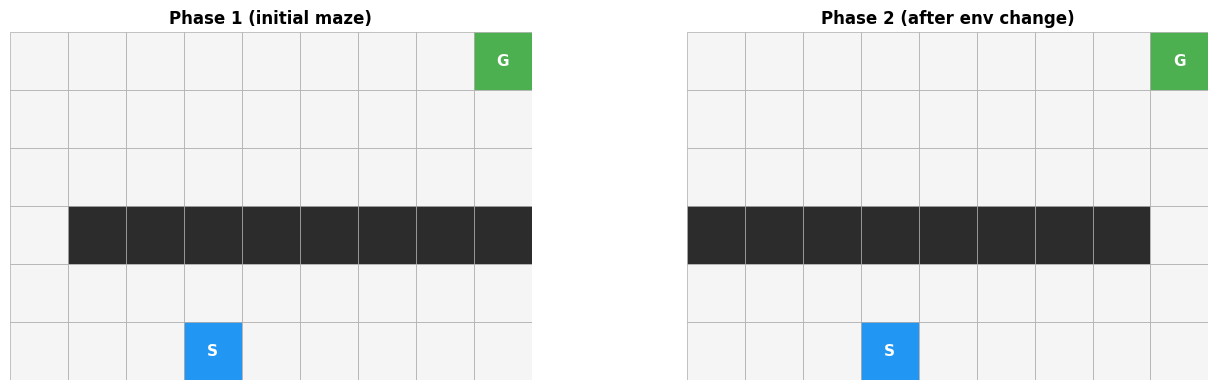

In [25]:


def run_experiment(total_steps=3000, switch_at=1000, n_runs=3, window=200, seed=69):
    random.seed(seed)
    np.random.seed(seed)
    results = {"Dyna-Q": [], "Dyna-Q+": [], "Dyna-AC": []}

    for _ in range(n_runs):
        agents = {
            "Dyna-Q":  DynaQ(54, 4),
            "Dyna-Q+": DynaQPlus(54, 4),
            "Dyna-AC": DynaAC(54, 4),
        }
        for name, agent in agents.items():
            maze = DynamicMaze()
            rewards = []

            s = maze.reset()
            for t in range(total_steps):
                if t == switch_at:
                    maze.switch_phase()

                # use your original agent's methods
                if isinstance(agent, DynaAC):
                    a = agent.sample_action(s)
                else:
                    a = agent.epsilon_greedy(s)

                r, sp = maze.step(s, a)
                rewards.append(r)

                # call your original run() logic manually
                agent.q_update(s, a, r, sp) if not isinstance(agent, DynaAC) else agent.ac_update(s, a, r, sp)

                if (s, a) not in agent.model:
                    agent.observed.append((s, a))
                agent.model[(s, a)] = (r, sp)

                if isinstance(agent, DynaQPlus):
                    agent.tau += 1
                    agent.tau[s, a] = 0

                for _ in range(agent.n):
                    ss, aa = random.choice(agent.observed)
                    rr, ssp = agent.model[(ss, aa)]
                    if isinstance(agent, DynaQPlus):
                        bonus = agent.kappa * np.sqrt(agent.tau[ss, aa])
                        td = (rr + bonus) + agent.gamma * np.max(agent.Q[ssp])
                        agent.Q[ss, aa] += agent.alpha * (td - agent.Q[ss, aa])
                    elif isinstance(agent, DynaAC):
                        agent.ac_update(ss, aa, rr, ssp)
                    else:
                        agent.q_update(ss, aa, rr, ssp)

                s = sp

            results[name].append(rewards)

    return results



def smooth(x, w=200):
    return np.convolve(x, np.ones(w)/w, mode='valid')

# Run
results = run_experiment(total_steps=3000, switch_at=1500, n_runs=3, window=200)

# ── Plot ──────────────────────────────────────────────────────
colors = {"Dyna-Q": "#2196f3", "Dyna-Q+": "#ff9800", "Dyna-AC": "#9c27b0"}
switch_at = 1000
window    = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dyna Variants on Dynamic Maze", fontsize=14, fontweight="bold")

# ── Cumulative reward ──
ax = axes[0]
for name, runs in results.items():
    mean = np.mean(runs, axis=0)
    ax.plot(np.cumsum(mean), label=name, color=colors[name], lw=2)
ax.axvline(switch_at, color="red", lw=1.5, linestyle="--", label="Env change")
ax.set_title("Cumulative reward")
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative reward")
ax.legend()
ax.grid(alpha=0.3)

# ── Smoothed reward rate ──
ax = axes[1]
for name, runs in results.items():
    mean = smooth(np.mean(runs, axis=0), window)
    ax.plot(mean, label=name, color=colors[name], lw=2)
ax.axvline(switch_at - window//2, color="red", lw=1.5, linestyle="--", label="Env change")
ax.set_title(f"Reward rate (smoothed, w={window})")
ax.set_xlabel("Step")
ax.set_ylabel("Avg reward")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Maze before/after ──
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
m1 = DynamicMaze(); m1.grid = m1.grid_phase1.copy()
m2 = DynamicMaze(); m2.grid = m2.grid_phase2.copy()
m1.show(title="Phase 1 (initial maze)", ax=ax1)
m2.show(title="Phase 2 (after env change)", ax=ax2)
plt.tight_layout()
plt.show()

## Lecture 9: Exploration and Exploitation

The multi-armed bandit setting and the explore/exploit trade-off: regret, upper confidence bounds, and Bayesian approaches.

# Exploration and Exploitation
**Exploitation** Make the best decision given current information

**Exploration** Gather more information

## The Multi-Armed Bandit


The *action-value* is the mean reward for action $a$,

$$Q(a) = \mathbb{E}[r \mid a]$$

 The *optimal value* $V^*$ is

$$V^* = Q(a^*) = \max_{a \in \mathcal{A}} Q(a)$$

The *regret* is the opportunity loss for one step

$$l_t = \mathbb{E}[V^* - Q(a_t)]$$

The *total regret* is the total opportunity loss

$$L_t = \mathbb{E}\left[ \sum_{\tau=1}^{t} V^* - Q(a_\tau) \right]$$

Maximise cumulative reward $\equiv$ minimise total regret

The *gap* $\Delta_a$ is the difference in value between action $a$ and optimal action $a^*$, $$\Delta_a = V^* - Q(a)$$

---
* Greedy has linear total regret
* ϵ-greedy has linear total regret
* also the 2 exploration methods + optimistic initialisation has linear total regret ( initialise Q(a) to high value )
* Decaying $\epsilon_t$-greedy has *logarithmic* asymptotic total regret!


⇒ Pick a decay schedule for $\epsilon_1, \epsilon_2, \dots$
Consider the following schedule

$$c > 0$$

$$d = \min_{a \mid \Delta_a > 0} \Delta_i$$

$$\epsilon_t = \min \left\{ 1, \frac{c|\mathcal{A}|}{d^2t} \right\}$$

---
(lower bound)

### Theorem (Lai and Robbins)

*Asymptotic total regret is at least logarithmic in number of steps*

$$\lim_{t \to \infty} L_t \geq \log t \sum_{a \mid \Delta_a > 0} \frac{\Delta_a}{KL(\mathcal{R}^a \parallel \mathcal{R}^{a^*})}$$

* $L_t$ represents the Expected Cumulative Regret
* $\Delta_a$The optimality gap
* The Kullback-Leibler (KL) → If a suboptimal arm looks very different from the best arm (high KL divergence), it is easy to identify, so you will pull it fewer times (lower regret).

---
#UCB (Upper Certain Bound)

 Estimate an upper confidence $\hat{U}_t(a)$ for each action value (Uncertainty is represented by the variance ($\sigma^2$) or standard deviation ($\sigma$) of the curve. A wider curve means higher variance (more uncertainty).)

Such that $Q(a) \le \hat{Q}_t(a) + \hat{U}_t(a)$ with high probability

This depends on the number of times $N(a)$ has been selected
* Small $N_t(a) \implies$ large $\hat{U}_t(a)$ (estimated value is uncertain)
* Large $N_t(a) \implies$ small $\hat{U}_t(a)$ (estimated value is accurate)

Select action maximising Upper Confidence Bound (UCB)

$$a_t = \underset{a \in \mathcal{A}}{\operatorname{argmax}} \; \hat{Q}_t(a) + \hat{U}_t(a)$$

based on some proofs we get this:
$$U_t(a) = \sqrt{\frac{2 \log t}{N_t(a)}}$$


*The UCB algorithm achieves logarithmic asymptotic total regret*

$$\lim_{t \to \infty} L_t \le 8 \log t \sum_{a \mid \Delta_a > 0} \Delta_a$$

---
## Bayesian Bandits

**Bayesian bandits** exploit prior knowledge of rewards, $p[\mathcal{R}]$

They compute posterior distribution of rewards $p[\mathcal{R} \mid h_t]$
* where $h_t = a_1, r_1, \dots, a_{t-1}, r_{t-1}$ is the history

Use posterior to guide exploration
* Upper confidence bounds (Bayesian UCB)
* Probability matching (Thompson sampling)

### Bayesian UCB example
Assume reward distribution is Gaussian, $\mathcal{R}_a(r) = \mathcal{N}(r; \mu_a, \sigma_a^2)$

Pick action that maximises standard deviation of Q(a)
$$a_t = \operatorname{argmax} \mu_a + c \sigma_a / \sqrt{N(a)}$$

### Probability Matching
**Probability matching** selects action $a$ according to probability that $a$ is the optimal action

$$\pi(a \mid h_t) = \mathbb{P} \left[ Q(a) > Q(a'), \forall a' \neq a \;\middle|\; h_t \right]$$

Probability matching is optimistic in the face of uncertainty
* Uncertain actions have higher probability of being max

### Thompson Sampling

Every time it is time to make a choice, Thompson Sampling does the following:

Sample: Look at the probability distributions for all available actions. From each distribution, randomly draw one single number ($Q$-value).

Choose: Compare the sampled numbers. Pick the action that generated the highest value.

Observe: Pull that arm and observe the actual reward you get from the environment.

Update: Use that new reward to update the probability distribution for that specific arm (using Bayes' Theorem), making your future guesses more accurate.

---
### Information State Space
* Each action $a$ causes a transition to a new information state $\tilde{s}'$ (by adding information), with probability $\tilde{\mathcal{P}}_{\tilde{s},\tilde{s}'}^a$
* This defines MDP $\tilde{\mathcal{M}}$ in augmented information state space

$$\tilde{\mathcal{M}} = \langle \tilde{\mathcal{S}}, \mathcal{A}, \tilde{\mathcal{P}}, \mathcal{R}, \gamma \rangle$$

Solving Information State Space Bandits:

Model-free reinforcement learning
* e.g. Q-learning (Duff, 1994)
Bayesian model-based reinforcement learning
* e.g. Gittins indices (Gittins, 1979)
* This approach is known as *Bayes-adaptive* RL
* Finds Bayes-optimal exploration/exploitation trade-off with respect to prior distribution

---
## Linear UCB

$$Q(s, a) = \mathbb{E} \, [r \mid s, a]$$

Estimate value function with a linear function approximator
$$Q_\theta(s, a) = \phi(s, a)^\top \theta \approx Q(s, a)$$

$$A_t = \sum_{\tau=1}^t \phi(s_\tau, a_\tau) \phi(s_\tau, a_\tau)^\top$$

$$b_t = \sum_{\tau=1}^t \phi(s_\tau, a_\tau) r_\tau$$

$$\theta_t = A_t^{-1} b_t$$

Calculating Linear Upper Confidence Bounds
$$a_t = \underset{a \in \mathcal{A}}{\operatorname{argmax}} \; Q_\theta(s_t, a) + c \sqrt{\phi(s_t, a)^\top A_t^{-1} \phi(s_t, a)}$$

---
* Optimistic Initialisation: Model-Free RL :
Initialise action-value function $Q(s, a)$ to $\frac{r_{\max}}{1-\gamma}$
* Optimistic Initialisation: Model-Based RL : Construct an optimistic model of the MDP
Initialise transitions to go to heaven

---

# UCB

In [26]:
import numpy as np

class UCB:
    def __init__(self, n_arms: int, c: float = 1.0):
        self.n_arms = n_arms
        self.c = c
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.n_arms)
        self.N = np.zeros(self.n_arms)
        self.t = 0

    def select_action(self) -> int:
        self.t += 1
        unvisited = np.where(self.N == 0)[0]
        if len(unvisited):
            return int(unvisited[0])
        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return int(np.argmax(ucb))

    def update(self, action: int, reward: float):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

In [27]:
np.random.seed(65)
true_means = [0.2, 1.5, 0.8, -0.3, 1.0]  # 5-armed bandit
agent = UCB(n_arms=5, c=1.0)

for _ in range(1000):
    a = agent.select_action()
    r = np.random.normal(true_means[a], 1.0)   # Gaussian reward
    agent.update(a, r)

print("Q estimates:", np.round(agent.Q, 3))
print("Visit counts:", agent.N.astype(int))
print("Best arm found:", np.argmax(agent.Q))   # should be 1

Q estimates: [ 0.374  1.482  0.907 -0.892  0.812]
Visit counts: [  5 963  16   2  14]
Best arm found: 1


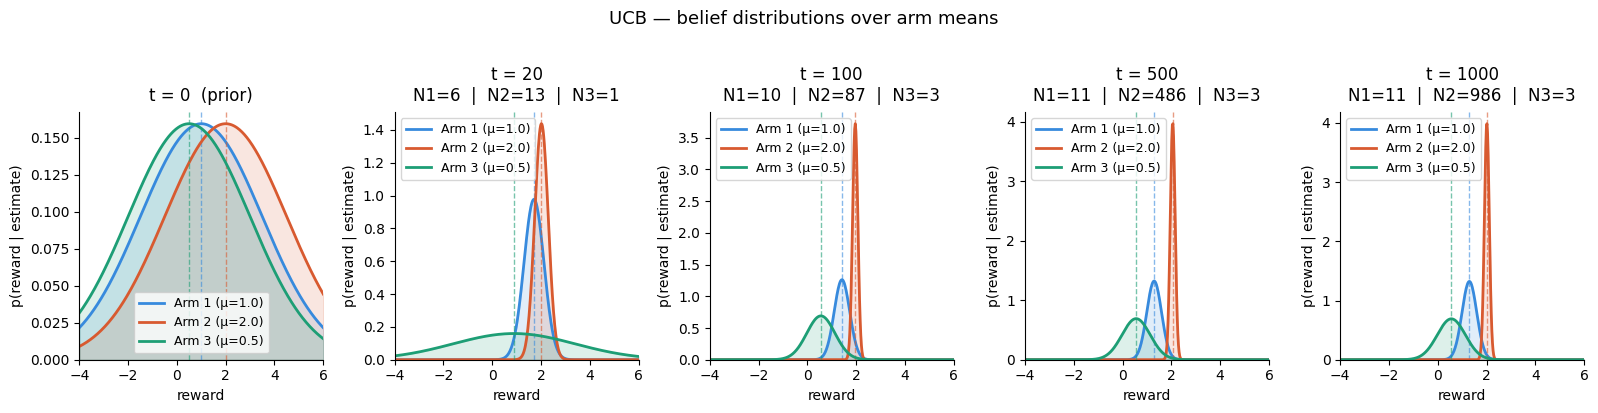

In [28]:
import numpy as np
import matplotlib.pyplot as plt

TRUE_MEANS = [1.0, 2.0, 0.5]
TRUE_STD   = 1.0
N_ARMS     = 3
COLORS     = ['#378ADD', '#D85A30', '#1D9E75']
ARM_LABELS = ['Arm 1 (μ=1.0)', 'Arm 2 (μ=2.0)', 'Arm 3 (μ=0.5)']

def sample_reward(arm: int) -> float:
    return np.random.normal(TRUE_MEANS[arm], TRUE_STD)

# ── Plotting ──────────────────────────────────────────────────────────────────

def estimated_sigma(N_i: float) -> float:
    """Uncertainty of the mean estimate: shrinks as 1/sqrt(N)."""
    if N_i < 2:
        return 2.5
    return max(0.1, 1.0 / np.sqrt(N_i))

def plot_distributions(agent: UCB, title: str, ax: plt.Axes):
    x = np.linspace(-4, 6, 400)
    for i in range(N_ARMS):
        mu    = agent.Q[i] if agent.N[i] > 0 else TRUE_MEANS[i]
        sigma = estimated_sigma(agent.N[i])
        pdf   = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
        ax.plot(x, pdf, color=COLORS[i], linewidth=2, label=ARM_LABELS[i])
        ax.fill_between(x, pdf, alpha=0.15, color=COLORS[i])
        ax.axvline(mu, color=COLORS[i], linewidth=1, linestyle='--', alpha=0.6)

    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel('reward')
    ax.set_ylabel('p(reward | estimate)')
    ax.legend(fontsize=9)
    ax.set_xlim(-4, 6)
    ax.set_ylim(bottom=0)
    ax.spines[['top', 'right']].set_visible(False)

# ── Run ───────────────────────────────────────────────────────────────────────

SNAPSHOTS  = [0,20 ,100 , 500, 1000]   # steps at which to plot
TOTAL_STEPS = SNAPSHOTS[-1]

agent = UCB(n_arms=N_ARMS, c=1.0)

fig, axes = plt.subplots(1, len(SNAPSHOTS), figsize=(16, 4), sharey=False)
fig.suptitle('UCB — belief distributions over arm means', fontsize=13, y=1.02)

snap_idx = 0

# plot t=0 before any steps
if SNAPSHOTS[0] == 0:
    plot_distributions(agent, f't = 0  (prior)', axes[0])
    snap_idx = 1

for step in range(1, TOTAL_STEPS + 1):
    a = agent.select_action()
    r = sample_reward(a)
    agent.update(a, r)

    if snap_idx < len(SNAPSHOTS) and step == SNAPSHOTS[snap_idx]:
        n_str = '  |  '.join(f'N{i+1}={int(agent.N[i])}' for i in range(N_ARMS))
        plot_distributions(agent, f't = {step}\n{n_str}', axes[snap_idx])
        snap_idx += 1

plt.tight_layout()
plt.savefig('ucb_distributions.png', dpi=150, bbox_inches='tight')
plt.show()